# Evaluate pipeline

In [2]:
import cv2

# Custom imports
from src.segmentation_pipeline import segmentation_pipeline
from src.model_run import start_prediction_machine, detectron2_instances
from src.classic_instances import instance_regions
from src.fusion import fusion_of_masks
# from src.classifier import reclassify_instances
from src.coco_json_functions import export_to_coco, labelme_to_coco
from src.helper_functions.image_functions import show_image
from src.classifier import classify_instances, load_classifiers, Category_Classifier
from src.model_run import CLASSES

# Required imports for classifiers
from sklearn.base import TransformerMixin, BaseEstimator
class SelectColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, xs, ys, **params):
        return self
    def transform(self, xs):
        return xs[self.columns]

# Generate output coco files

In [3]:
# Image
# img_path = "/home/mellanie/Desktop/pipeline_code/20250129_N4_Plate6_DAG6_1000_L/000018.tif"
# img_annotations = "/home/mellanie/Desktop/pipeline_code/20250129_N4_Plate6_DAG6_1000_L/labelme_annotations/000018.json"

img_path = "/home/mellanie/Desktop/annotations/masks_from_manual_annotations/Plate_2/000004.tif"
img_annotations = "/home/mellanie/Desktop/annotations/training_set/labelme_annotations_2/000004.json" # needs to be the json

# ///////////////////////////////////////////////////////////

# Model to use
model_path = "/home/mellanie/Desktop/container/model/segmentation_models/instance_no_root.pth"

# Classifiers
bmp_cls = "/home/mellanie/Desktop/container/model/classifiers/bumps_embedded_classifier.pkl"
bg_cls = "/home/mellanie/Desktop/container/model/classifiers/bg_regular_classifier.pkl"

In [6]:
# predictor is the segmentaion model as a variable
predictor = start_prediction_machine(path_to_model=model_path, multi_class=True)

# Make the classifier class
bmp_predictor, bg_predictor = load_classifiers(bmp_cls, bg_cls)
classifier = Category_Classifier(None, None, None, None, bmp_predictor, bg_predictor)


def instance_segmentation_pipeline(img_path):
    
    #1. Classic Segmentation
    #   function returns the mask for the root and the mask for the hairs as seperate variables
    root, hairs = segmentation_pipeline(img_path, verbose = False, show_overlay=False)

    #2. Separate Classic Segments by Instance
    #   get a list of each unique instance mask of root hairs
    classic_instances = instance_regions(hairs, root)
    
    #3. Get the Model outputs
    #   Instances is a list of all found instances in the image, including bounding box, mask, label, and label id
    model_instances = detectron2_instances(predictor, img_path)

    #4. Fuseion
    fused_instances = fusion_of_masks(classic_instances, model_instances)

    #5. Classify
    classified_instances = classify_instances(fused_instances, root, img_path, classifier)
    
    # OPTIONAL: Destinguish between classic and model
    classic_instances = [inst for inst in classified_instances if inst["case"] != "C"]
    model_instances = [inst for inst in classified_instances if inst["case"] != "B"]

    export_to_coco(classified_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/segmentation_outputs_coco.json")
    export_to_coco(classic_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/classic_outputs_coco.json")
    export_to_coco(model_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/model_outputs_coco.json")

    return classified_instances

/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Tr

In [7]:
%%capture
# generate a coco file using the pipeline we have built.
final_instances = instance_segmentation_pipeline(img_path)

# generate a coco file from the label me annotations
labelme_to_coco(img_annotations, img_path, CLASSES, image_id=0)

# Evaluate files

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils


def load_coco(path):
    with open(path, "r") as f:
        return json.load(f)


def polygon_to_mask(segmentation, height, width):
    """Convert one annotation's polygon segmentation into a binary mask."""
    rles = mask_utils.frPyObjects(segmentation, height, width)
    rle = mask_utils.merge(rles)
    return mask_utils.decode(rle)


def build_flattened_mask(coco_data, image_id=0):
    """
    MANDATORY PARAMETERS:
        coco_data -- loaded COCO dict
        image_id  -- which image's annotations to flatten

    OUTPUT:
        single 2D binary mask (union of every annotation for that image)
    """
    image_info = next(img for img in coco_data["images"])
    height, width = image_info["height"], image_info["width"]

    flattened = np.zeros((height, width), dtype=np.uint8)

    anns = [a for a in coco_data["annotations"]]

    for ann in anns:
        # if ann['category_id'] != 0:
        inst_mask = polygon_to_mask(ann["segmentation"], height, width)
        flattened = np.logical_or(flattened, inst_mask).astype(np.uint8)

    return flattened

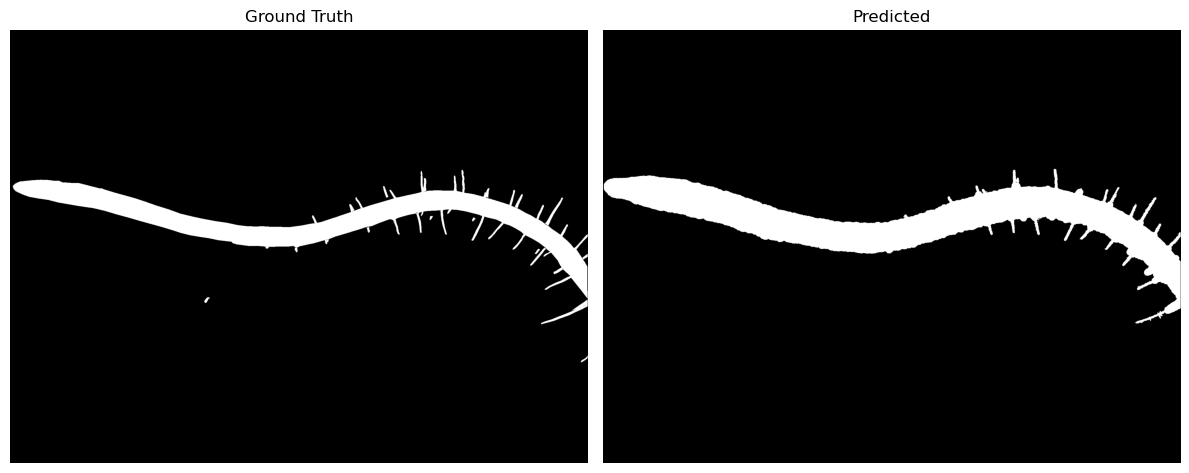

In [9]:
truth = "outputs/ground_truth_coco.json"
predicted = "outputs/segmentation_outputs_coco.json"

true_coco_data = load_coco(truth)
predicted_coco_data = load_coco(predicted)

true_flat_mask = build_flattened_mask(true_coco_data)
predicted_flat_mask = build_flattened_mask(predicted_coco_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(true_flat_mask, cmap="gray")
axes[0].axis("off")
axes[0].set_title("Ground Truth")

axes[1].imshow(predicted_flat_mask, cmap="gray")
axes[1].axis("off")
axes[1].set_title("Predicted")

plt.tight_layout()
plt.show()

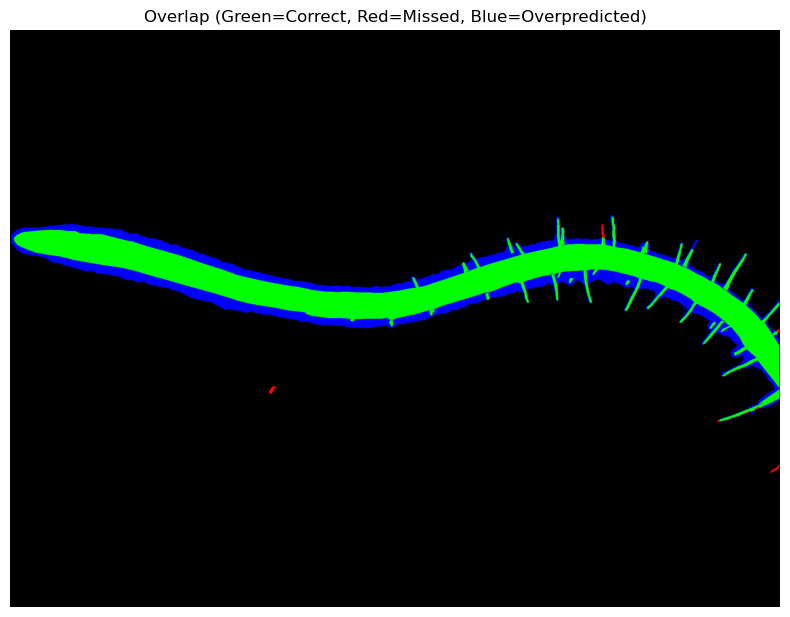

In [10]:

true_bool = true_flat_mask.astype(bool)
pred_bool = predicted_flat_mask.astype(bool)

correct_overlap = np.logical_and(true_bool, pred_bool)      # both agree: green
false_positive = np.logical_and(pred_bool, ~true_bool)      # predicted only: red
false_negative = np.logical_and(true_bool, ~pred_bool)      # missed by pred: red

# build an RGB image
height, width = true_flat_mask.shape
overlay = np.zeros((height, width, 3), dtype=np.uint8)

overlay[correct_overlap] = [0, 255, 0]      # green
overlay[false_positive] = [0, 0, 255]       # red
overlay[false_negative] = [255, 0, 0]       # red 

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title("Overlap (Green=Correct, Red=Missed, Blue=Overpredicted)")
plt.tight_layout()
plt.show()

# Per Instance Evaluation Code

In [11]:
from scipy.optimize import linear_sum_assignment
from pycocotools import mask as mask_utils



def compute_iou(mask_a, mask_b):
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return intersection / union if union > 0 else 0.0


def Per_Instance_Evaluation(pred_anns, gt_anns, height, width,
                                     iou_threshold=0.5, limit=None):
    """
    Match predicted instances to ground truth instances by area overlap
    (IoU) only.

    MANDATORY PARAMETERS:
        pred_anns -- list of predicted COCO annotation dicts (single image)
        gt_anns   -- list of ground truth COCO annotation dicts (single image)
        height, width -- image dimensions for polygon decoding

    OPTIONAL PARAMETERS:
        iou_threshold -- minimum IoU to count as a valid match (default 0.5)
        limit -- if set, only process the first N predicted instances
                 (excluding root, category_id == 0)

    OUTPUT:
        list of match dicts, one per predicted instance considered:
        {
            "pred_id": ...,
            "pred_category": ...,
            "matched_gt_id": ... or None,
            "matched_gt_category": ... or None,
            "iou": ...,
            "category_match": True/False/None,
        }
    """
    # Tristan note: filter out root (category_id == 0) from BOTH sides --
    # root is handled separately and shouldn't compete for matches or
    # inflate/deflate the instance-matching stats
    pred_filtered = [a for a in pred_anns if a["category_id"] != 0]
    gt_filtered = [a for a in gt_anns if a["category_id"] != 0]

    if limit is not None:
        pred_filtered = pred_filtered[:limit]

    if len(pred_filtered) == 0 or len(gt_filtered) == 0:
        return [
            {
                "pred_id": a["id"],
                "pred_category": a["category_id"],
                "matched_gt_id": None,
                "matched_gt_category": None,
                "iou": 0.0,
            }
            for a in pred_filtered
        ]

    # decode masks once, up front, so we're not re-decoding polygons
    # inside the IoU double loop
    pred_masks = [polygon_to_mask(a["segmentation"], height, width) for a in pred_filtered]
    gt_masks = [polygon_to_mask(a["segmentation"], height, width) for a in gt_filtered]

    # build IoU cost matrix (area-only, category-agnostic)
    n_pred, n_gt = len(pred_masks), len(gt_masks)
    iou_matrix = np.zeros((n_pred, n_gt), dtype=np.float64)

    for i in range(n_pred):
        for j in range(n_gt):
            iou_matrix[i, j] = compute_iou(pred_masks[i], gt_masks[j])

    # Hungarian algorithm -- guarantees a 1-to-1 assignment, so no
    # predicted instance can be paired with more than one ground truth
    # instance and vice versa. This is what enforces "no duplicates."
    cost_matrix = -iou_matrix
    pred_idx, gt_idx = linear_sum_assignment(cost_matrix)

    # map assignment results back onto predicted instances
    assignment = {p_i: g_i for p_i, g_i in zip(pred_idx, gt_idx)}

    results = []
    for i, pred_ann in enumerate(pred_filtered):
        if i in assignment and iou_matrix[i, assignment[i]] >= iou_threshold:
            gt_i = assignment[i]
            gt_ann = gt_filtered[gt_i]
            results.append({
                "pred_id": pred_ann["id"],
                "pred_category": pred_ann["category_id"],
                "matched_gt_id": gt_ann["id"],
                "matched_gt_category": gt_ann["category_id"],
                "iou": float(iou_matrix[i, gt_i]),
            })
        else:
            # no ground truth instance overlapped this prediction enough
            results.append({
                "pred_id": pred_ann["id"],
                "pred_category": pred_ann["category_id"],
                "matched_gt_id": None,
                "matched_gt_category": None,
                "iou": 0.0,
            })

    return results





In [24]:
truth_path = "outputs/ground_truth_coco.json"
predicted_path = "outputs/model_outputs_coco.json"

image_id = 0

truth = load_coco(truth_path)
predicted = load_coco(predicted_path)

image_info = next(img for img in truth["images"] if img["id"] == image_id) # 0 is the image id
height, width = image_info["height"], image_info["width"]

predicted_segments = [a for a in predicted["annotations"] if a["image_id"] == image_id and a["category_id"] != 0]
true_segments = [a for a in truth["annotations"] if a["image_id"] == image_id and a["category_id"] != 0]

npred = len(predicted_segments)
ntrue = len(true_segments)


print("Predicted: ", npred)
print("Aktual: ", ntrue)


Predicted:  28
Aktual:  54


In [25]:
matches = Per_Instance_Evaluation(predicted_segments, true_segments, height, width, iou_threshold=0.35)

In [26]:
matched_gt_ids = {m["matched_gt_id"] for m in matches if m["matched_gt_id"] is not None}
gt_by_id = {a["id"]: a for a in true_segments}
pred_by_id = {a["id"]: a for a in predicted_segments}


false_negatives = [gt for gt in true_segments if gt["id"] not in matched_gt_ids]
FN = len(false_negatives)


true_positives = [gt_by_id[m["matched_gt_id"]] for m in matches if m["matched_gt_id"] is not None]
TP = len(true_positives)

false_positives = [pred_by_id[m["pred_id"]] for m in matches if m["matched_gt_id"] is None]
FP = len(false_positives)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"TP={TP}  FP={FP}  FN={FN}")
print(f"Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")

TP=27  FP=1  FN=27
Precision=0.9643  Recall=0.5000  F1=0.6585


In [27]:
print(true_positives)
print(false_negatives)
print(false_positives)

[{'id': 2, 'image_id': 0, 'category_id': 5, 'segmentation': [[2046.5811767578125, 970.940185546875, 2038.0341796875, 977.3504028320312, 2020.940185546875, 986.3247680664062, 1997.008544921875, 996.1538696289062, 1967.94873046875, 1008.11962890625, 1943.5897216796875, 1017.5213623046875, 1919.6580810546875, 1027.3504638671875, 1895.2991943359375, 1035.042724609375, 1881.6239013671875, 1040.5982666015625, 1882.05126953125, 1045.2991943359375, 1899.5726318359375, 1040.5982666015625, 1926.4957275390625, 1033.3333740234375, 1953.84619140625, 1023.076904296875, 1982.4786376953125, 1012.8204956054688, 2004.7008056640625, 1001.7094116210938, 2026.068359375, 992.3076782226562, 2039.3162841796875, 985.4700927734375, 2047.0, 981.8303833007812]], 'bbox': [1881.6239013671875, 970.940185546875, 165.3760986328125, 74.3590087890625], 'area': 1414.0, 'iscrowd': 0}, {'id': 33, 'image_id': 0, 'category_id': 1, 'segmentation': [[1894.871826171875, 688.0341796875, 1900.0, 684.1880493164062, 1910.6837158203

In [28]:
'''
Per Instance Results for image 2-4

Combined:
Predicted:  31
TP=22  FP=9  FN=32
Precision=0.7097  Recall=0.4074  F1=0.5176

Classic:
Predicted:  27
TP=21  FP=6  FN=33
Precision=0.7778  Recall=0.3889  F1=0.5185

Model:
Predicted:  28
TP=21  FP=7  FN=33
Precision=0.7500  Recall=0.3889  F1=0.5122


'''

'\nPer Instance Results for image 2-4\n\nCombined:\nPredicted:  31\nTP=22  FP=9  FN=32\nPrecision=0.7097  Recall=0.4074  F1=0.5176\n\nClassic:\nPredicted:  27\nTP=21  FP=6  FN=33\nPrecision=0.7778  Recall=0.3889  F1=0.5185\n\nModel:\nPredicted:  28\nTP=21  FP=7  FN=33\nPrecision=0.7500  Recall=0.3889  F1=0.5122\n\n\n'

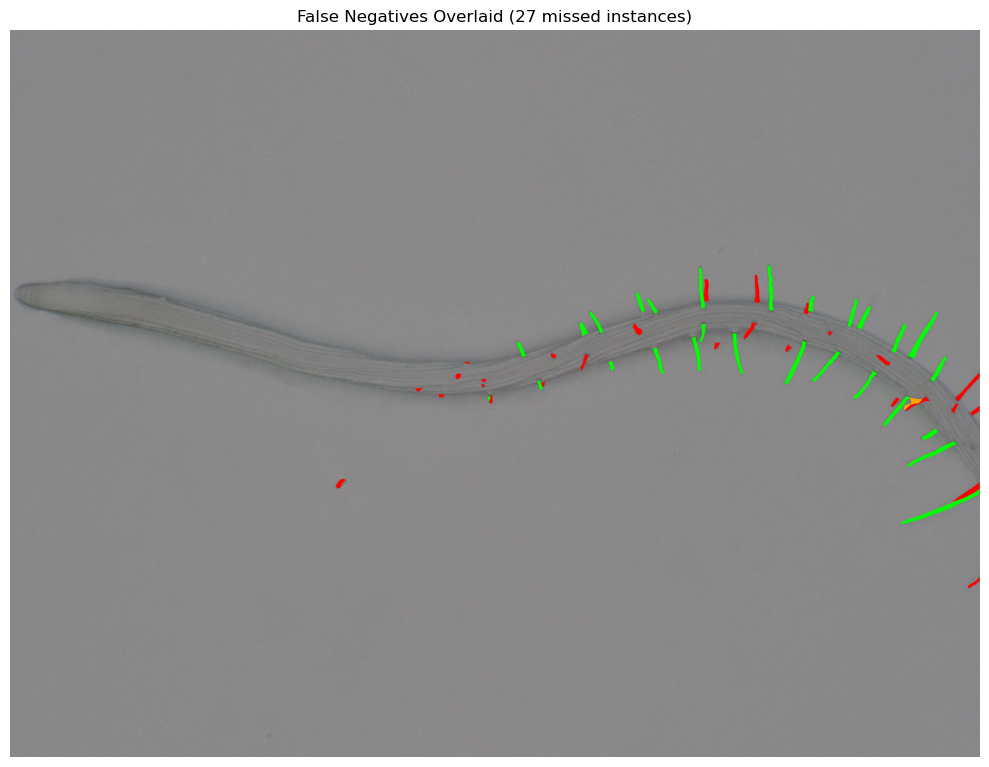

In [29]:

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

overlay = img_rgb.copy()

for fn in false_negatives:
    mask = polygon_to_mask(fn["segmentation"], height, width).astype(bool)
    overlay[mask] = [255, 0, 0]  # red

for tp in true_positives:
    mask = polygon_to_mask(tp["segmentation"], height, width).astype(bool)
    overlay[mask] = [0, 255, 0]  # red

for fp in false_positives:
    mask = polygon_to_mask(fp["segmentation"], height, width).astype(bool)
    overlay[mask] = [255, 165, 0]  # orange = false positive 


plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.axis("off")
plt.title(f"False Negatives Overlaid ({len(false_negatives)} missed instances)")
plt.tight_layout()
plt.show()

# Pixel based evaluation

This evaluation metric will be